In [1]:
import sys, pandas as pd
print(sys.executable)

file_path = "/home/ftk3187/github/PSED/0216_dataset/dataset.xlsx"
df = pd.read_excel(file_path, header=0)
df.columns = df.columns.str.strip()
df.reset_index(drop=True, inplace=True)
df["unique_id"] = df.index
df = df[["unique_id"] + [c for c in df.columns if c != "unique_id"]]

selected = ["unique_id","reactA","reactAT","reactB","reactBT","reactC","reactCT","reactD","reactDT","pc","reactScheme","coating","supports","supportsCat","batchmass","dp","pV","areaSSA","particlesize","processpressure","flow","pretreat_medium","pretreat_T","A_dosing","A_T","B_dosing","B_T","C_dosing","C_T","D_dosing","D_T","cycles","GPC"]

df_model = df[[c for c in selected if c in df.columns]].copy()

if "reactant" in str(df_model.iloc[0]["reactA"]).lower():
    df_model = df_model.iloc[1:].reset_index(drop=True)

output_path = "/home/ftk3187/github/PSED/0216_dataset/dataset_model_input.csv"
df_model.to_csv(output_path, index=False)

print("Saved:", output_path)


/home/ftk3187/miniconda3/envs/psed/bin/python
Saved: /home/ftk3187/github/PSED/0216_dataset/dataset_model_input.csv


In [2]:
import re, numpy as np

df_model["GPC"] = df_model["GPC"].astype(str).str.strip()

def split_gpc(x):
    m = re.match(r"^\s*([\d\.]+)\s*([^\d\s]+)?", x)
    return (m.group(1), m.group(2)) if m else (np.nan,np.nan)

df_model[["GPC_value_raw","GPC_unit_raw"]] = df_model["GPC"].apply(lambda x: pd.Series(split_gpc(x)))

print("Detected GPC units:")
print(df_model["GPC_unit_raw"].value_counts(dropna=False))

allowed_units = ["nm","nm/cycle","A","Å","A/cycle","Å/cycle"]
df_model["GPC_unit_clean"] = df_model["GPC_unit_raw"].where(df_model["GPC_unit_raw"].isin(allowed_units))
df_model["GPC_value"] = pd.to_numeric(df_model["GPC_value_raw"], errors="coerce")

def convert_to_nm(row):
    v,u = row["GPC_value"],row["GPC_unit_clean"]
    if pd.isna(v) or pd.isna(u): return np.nan
    return v*0.1 if u in ["A","Å","A/cycle","Å/cycle"] else v

df_model["GPC_nm"] = df_model.apply(convert_to_nm, axis=1)

print("\nCleaned GPC preview:")
print(df_model[["GPC","GPC_value","GPC_unit_clean","GPC_nm"]].head())

## filter out gpc > 2
df_model = df_model[df_model["GPC_nm"] <= 2].copy()


Detected GPC units:
GPC_unit_raw
NaN           2585
nm             202
A              162
None           106
Å               69
wt%             20
atomic          19
-               15
A/cycle          7
nm/cycle         7
area/cycle       5
wt.%/cycle       5
mg/g             5
wt.%             4
*                4
Ti/nm            4
%                3
Al/nm            2
ppm/cycle        2
e                2
ML               2
ng/(cm           1
monolayer        1
Å/               1
atoms/nm         1
–                1
/                1
ng/cm            1
+                1
Si/nm            1
Name: count, dtype: int64

Cleaned GPC preview:
                GPC  GPC_value GPC_unit_clean  GPC_nm
0  0.3 atomic layer        0.3            NaN     NaN
1  0.7 atomic layer        0.7            NaN     NaN
2    1 atomic layer        1.0            NaN     NaN
3    2 atomic layer        2.0            NaN     NaN
4    3 atomic layer        3.0            NaN     NaN


In [25]:
import re
import numpy as np

for col in ["A_T","B_T", "reactAT","reactBT","reactCT","reactDT",
            "A_dosing", "B_dosing", "C_dosing", "D_dosing",
            "processpressure", "flow", "cycles", "areaSSA","particlesize"]:

    df_model[col] = (
        df_model[col]
        .astype(str)
        .str.strip()
        .replace({"RT": "25", "rt": "25"})
    )

    def dash_to_mean(x):
        if pd.isna(x):
            return np.nan

        x = str(x).strip()

        # 1️⃣ "<숫자" 또는 "< 숫자" → 숫자만 추출
        m_lt = re.match(r"^<\s*(\d+\.?\d*)$", x)
        if m_lt:
            return float(m_lt.group(1))

        # 2️⃣ "숫자 - 숫자" → 평균
        m_range = re.match(r"^\s*(\d+\.?\d*)\s*-\s*(\d+\.?\d*)\s*$", x)
        if m_range:
            return (float(m_range.group(1)) + float(m_range.group(2))) / 2

        # 3️⃣ 일반 숫자
        try:
            return float(x)
        except:
            return np.nan

    df_model[col] = df_model[col].apply(dash_to_mean)


In [26]:
# string cleaning
df_model["reactA"] = df_model["reactA"].astype(str).str.strip().str.upper()
df_model["reactB"] = df_model["reactB"].astype(str).str.strip().str.upper()
df_model["reactScheme"] = df_model["reactScheme"].astype(str).str.strip().str.upper()

# filter
df_TMA_H2O_AB = df_model[
    (df_model["reactA"] == "TMA") &
    (df_model["reactB"] == "H2O") &
    (df_model["reactScheme"] == "A-B") &
    (df_model["GPC_nm"].notna())
].copy()

print("Filtered dataset shape:", df_TMA_H2O_AB.shape)
df_TMA_H2O_AB.head()

Filtered dataset shape: (162, 38)


,unique_id,reactA,reactAT,reactB,reactBT,reactC,reactCT,reactD,reactDT,pc,...,C_T,D_dosing,D_T,cycles,GPC,GPC_value_raw,GPC_unit_raw,GPC_unit_clean,GPC_value,GPC_nm
111,112,TMA,25.0,H2O,25.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,150.0,0.1 nm,0.1,nm,nm,0.10,0.10
149,150,TMA,NaN,H2O,NaN,NaN,NaN,NaN,NaN,N2,...,NaN,NaN,NaN,50.0,0.12 nm,0.12,nm,nm,0.12,0.12
150,151,TMA,NaN,H2O,NaN,NaN,NaN,NaN,NaN,N2,...,NaN,NaN,NaN,100.0,0.12 nm,0.12,nm,nm,0.12,0.12
177,178,TMA,NaN,H2O,NaN,NaN,NaN,NaN,NaN,N2,...,NaN,NaN,NaN,50.0,0.5 nm,0.5,nm,nm,0.50,0.50
377,378,TMA,25.0,H2O,25.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,25.0,0.1 nm,0.1,nm,nm,0.10,0.10


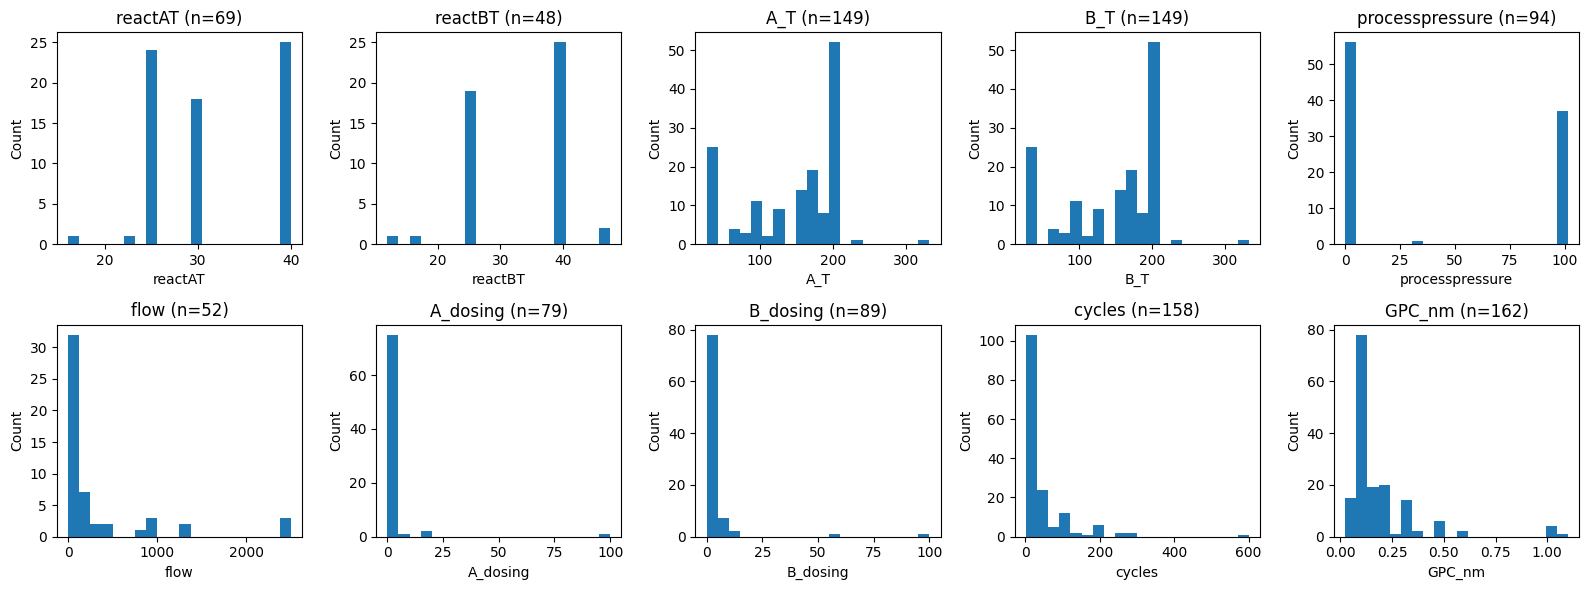

In [27]:
import matplotlib.pyplot as plt

vars_to_check = ["reactAT", "reactBT","A_T","B_T","processpressure","flow",
                 "A_dosing","B_dosing","cycles","GPC_nm"]


fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()

for i, var in enumerate(vars_to_check):
    data = df_TMA_H2O_AB[var]
    valid = data[data.notna()]   # 해당 변수만 기준으로 결측 제거
    axes[i].hist(valid, bins=20)
    axes[i].set_title(f"{var} (n={len(valid)})")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [28]:
from sklearn.model_selection import train_test_split

features=["supports","reactAT","reactBT","pc","coating","processpressure","flow",
          "A_T","B_T","cycles", "A_dosing","B_dosing", "areaSSA","particlesize"]

data=df_TMA_H2O_AB[features+["GPC_nm"]].copy()
X=pd.get_dummies(data[features],columns=["pc","coating","supports"],drop_first=True)
y=data["GPC_nm"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


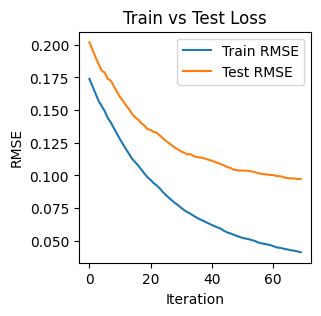

In [29]:
from xgboost import XGBRegressor

model=XGBRegressor(
    n_estimators=70,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="rmse",
    random_state=42
)

model.fit(
    X_train,y_train,
    eval_set=[(X_train,y_train),(X_test,y_test)],
    verbose=False
)

results=model.evals_result()
train_rmse=results["validation_0"]["rmse"]
test_rmse=results["validation_1"]["rmse"]

import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.plot(train_rmse,label="Train RMSE")
plt.plot(test_rmse,label="Test RMSE")
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.legend()
plt.title("Train vs Test Loss")
plt.show()



===== Test Performance =====
R2   : 0.7703761118829687
RMSE : 0.09690260292159075
MAE  : 0.061723193799907525


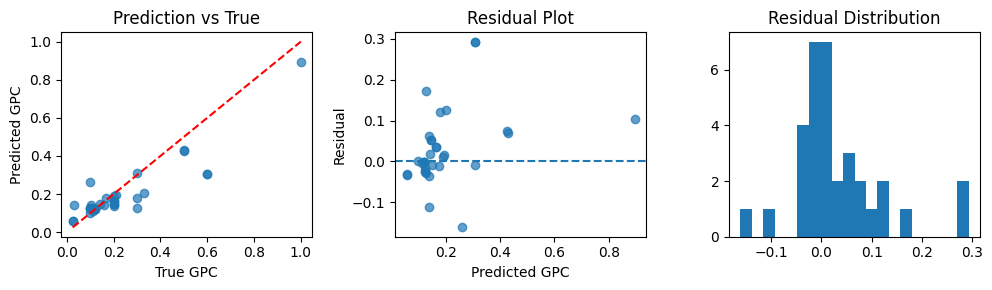

In [30]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("===== Test Performance =====")
print("R2   :", r2)
print("RMSE :", rmse)
print("MAE  :", mae)

residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(10,3))

# 1️⃣ Prediction vs True
axes[0].scatter(y_test, y_pred, alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel("True GPC")
axes[0].set_ylabel("Predicted GPC")
axes[0].set_title("Prediction vs True")

# 2️⃣ Residual plot
axes[1].scatter(y_pred, residuals, alpha=0.7)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Predicted GPC")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot")

# 3️⃣ Residual distribution
axes[2].hist(residuals, bins=20)
axes[2].set_title("Residual Distribution")

plt.tight_layout()
plt.show()


## ensemble

In [32]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

n_models = 3
models = []
all_importances = []
test_preds = []

for i in range(n_models):
    m = XGBRegressor(
        n_estimators=70,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="rmse",
        random_state=100+i
    )
    
    m.fit(X_train, y_train, verbose=False)
    
    models.append(m)
    test_preds.append(m.predict(X_test))
    
    imp = pd.Series(m.feature_importances_, index=X_train.columns)
    all_importances.append(imp)

# 예측 평균 / 불확실성
test_preds = np.array(test_preds)
y_mean = test_preds.mean(axis=0)
y_std  = test_preds.std(axis=0)

# importance 집계
imp_df = pd.concat(all_importances, axis=1)
imp_mean = imp_df.mean(axis=1).sort_values(ascending=False)

top5 = imp_mean.head(5).index.tolist()

print("Top 5 variables:")
print(top5)


Top 5 variables:
['areaSSA', 'cycles', 'A_T', 'B_T', 'pc_N2']


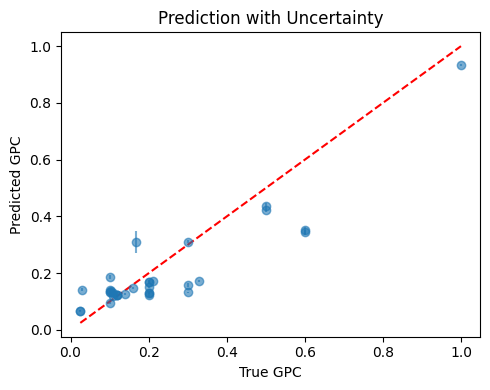

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.errorbar(y_test, y_mean, yerr=y_std, fmt='o', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("True GPC")
plt.ylabel("Predicted GPC")
plt.title("Prediction with Uncertainty")
plt.tight_layout()
plt.show()


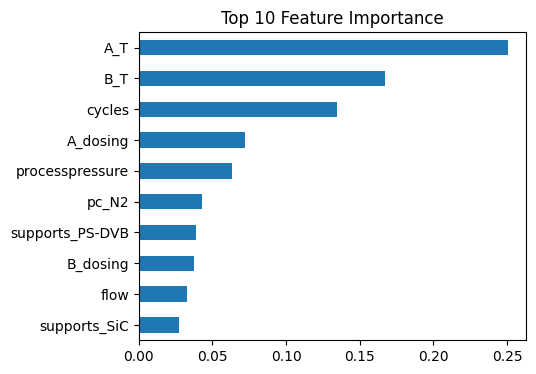

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

imp = pd.Series(model.feature_importances_, index=X.columns)

# 중요도 기준 정렬 후 상위 10개만 선택
top10 = imp.sort_values().tail(10)

top10.plot(kind="barh", figsize=(5,4))
plt.title("Top 10 Feature Importance")
plt.show()


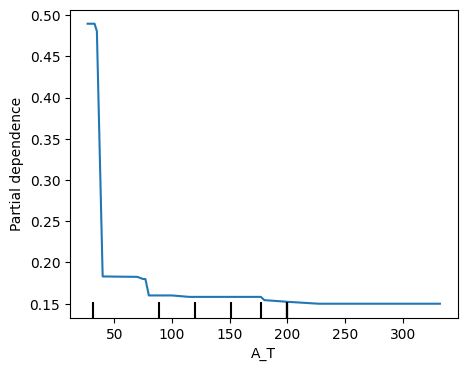

In [12]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(5,4))
PartialDependenceDisplay.from_estimator(model, X, ["A_T"], ax=ax)
plt.show()


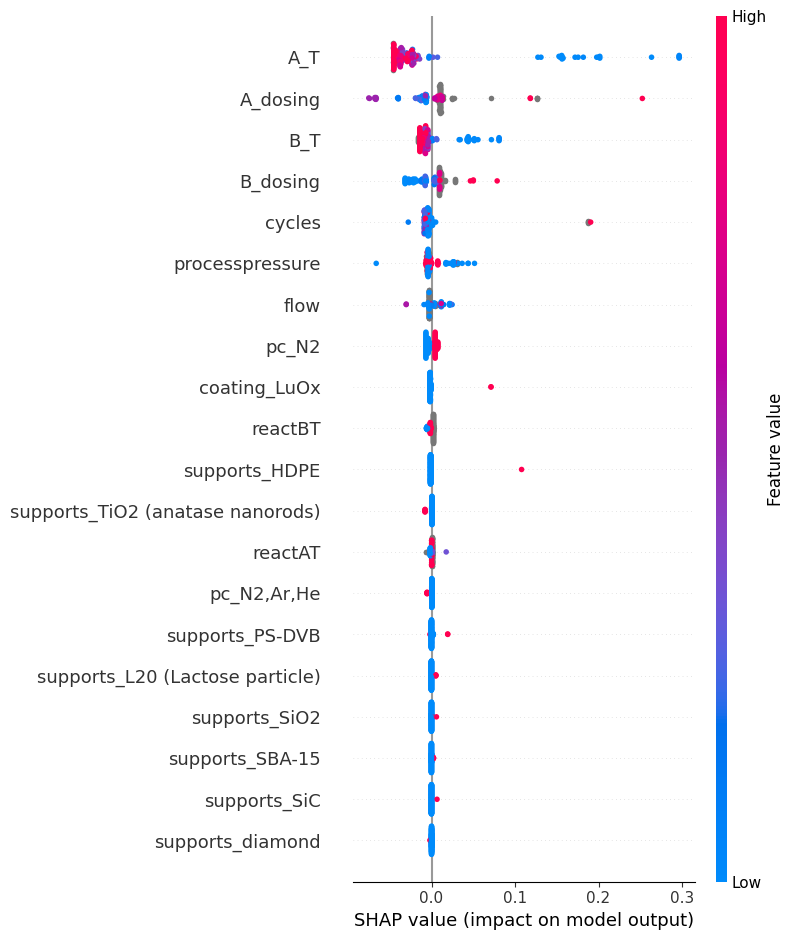

In [13]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)


In [14]:
vars_to_check = ["A_T","B_T","processpressure","flow","A_dosing","B_dosing","cycles","GPC_nm"]
df_TMA_H2O_AB[vars_to_check].describe()


,A_T,B_T,processpressure,flow,A_dosing,B_dosing,cycles,GPC_nm
count,149.000000,149.000000,94.000000,52.000000,79.000000,89.000000,158.000000,162.000000
mean,144.100671,144.100671,40.582273,331.009615,2.826799,3.499701,44.949367,0.191764
std,64.540972,64.540972,48.798593,641.850209,11.407050,12.316522,74.735866,0.185332
min,27.000000,27.000000,0.000100,0.500000,0.000250,0.000250,1.000000,0.023000
25%,100.000000,100.000000,0.425000,0.875000,0.083417,0.033300,5.000000,0.101000
50%,170.000000,170.000000,1.670000,50.000000,1.000000,1.000000,12.000000,0.120000
75%,200.000000,200.000000,100.000000,225.000000,2.000000,2.000000,50.000000,0.200000
max,332.000000,332.000000,101.325000,2500.000000,100.000000,100.000000,600.000000,1.100000
